In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# **AlexNet Architecture**
def build_alexnet(input_shape, num_classes):
    model = Sequential([
        Conv2D(96, (11, 11), strides=4, activation='relu', input_shape=input_shape),
        MaxPooling2D((3, 3), strides=2),
        BatchNormalization(),
        Dropout(0.6),  # Increased dropout rate
        Conv2D(256, (5, 5), padding='same', activation='relu'),
        MaxPooling2D((3, 3), strides=2),
        BatchNormalization(),
        Dropout(0.6),  # Increased dropout rate
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(384, (3, 3), padding='same', activation='relu'),
        Conv2D(256, (3, 3), padding='same', activation='relu'),
        MaxPooling2D((3, 3), strides=2),
        BatchNormalization(),
        Dropout(0.6),  # Increased dropout rate
        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.6),  # Increased dropout rate
        Dense(4096, activation='relu'),
        Dropout(0.6),  # Increased dropout rate
        Dense(num_classes, activation='softmax')  # Adjust based on your dataset
    ])

    optimizer = Adam(learning_rate=0.0001)  # Lower learning rate
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model

dataset_dir = 'C:/Users/DELL/OneDrive/Documents/majorProject/seedsBalanced'

# **Data Augmentation**
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,  # Increased rotation range
    width_shift_range=0.2,  # Increased width shift
    height_shift_range=0.2,  # Increased height shift
    shear_range=0.2,  # Increased shear range
    zoom_range=0.2,  # Increased zoom range
    horizontal_flip=True, 
    fill_mode='reflect',
    validation_split=0.2  # Splitting 20% for validation
)

# **Load Dataset**
train_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224, 224),
    batch_size=64,
    class_mode='categorical',
    subset='validation'
)

# **Build and Train the Model**
num_classes = len(train_gen.class_indices)
alexnet_model = build_alexnet(input_shape=(224, 224, 3), num_classes=num_classes)

# Learning Rate Scheduler
def lr_scheduler(epoch, lr):
    if epoch < 10:
        return lr
    else:
        return lr * 0.9  # Reduce learning rate by 10% after epoch 10

lr_callback = LearningRateScheduler(lr_scheduler)

# Callbacks
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)
early_stopping = EarlyStopping(monitor='val_loss', patience=29, restore_best_weights=True)

history = alexnet_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,  # Increased number of epochs
    callbacks=[reduce_lr, early_stopping, lr_callback]
)


# **Evaluate the Model**
val_loss, val_accuracy = alexnet_model.evaluate(val_gen)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')



Found 3134 images belonging to 8 classes.
Found 778 images belonging to 8 classes.


C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\DELL\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 447s 9s/step - accuracy: 0.3584 - loss: 2.6264 - val_accuracy: 0.1247 - val_loss: 4.0267 - learning_rate: 1.0000e-04
Epoch 2/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 388s 8s/step - accuracy: 0.8033 - loss: 0.5831 - val_accuracy: 0.1247 - val_loss: 7.6083 - learning_rate: 1.0000e-04
Epoch 3/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 435s 9s/step - accuracy: 0.8260 - loss: 0.5454 - val_accuracy: 0.1247 - val_loss: 8.7899 - learning_rate: 1.0000e-04
Epoch 4/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 381s 8s/step - accuracy: 0.8568 - loss: 0.4392 - val_accuracy: 0.1247 - val_loss: 8.9923 - learning_rate: 1.0000e-04
Epoch 5/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 386s 8s/step - accuracy: 0.8920 - loss: 0.3173 - val_accuracy: 0.1375 - val_loss: 8.8388 - learning_rate: 1.0000e-04
Epoch 6/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 468s 10s/step - accuracy: 0.9085 - loss: 0.2655 - val_accuracy: 0.1478 - val_loss: 13.9397 - learning_rate: 1.0000e-04
Epoch 7/30
49/49 ━━━━━━━━━━━━━━━━━━━━ 448s 9s/step - accuracy: 0.912

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 990ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step   
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


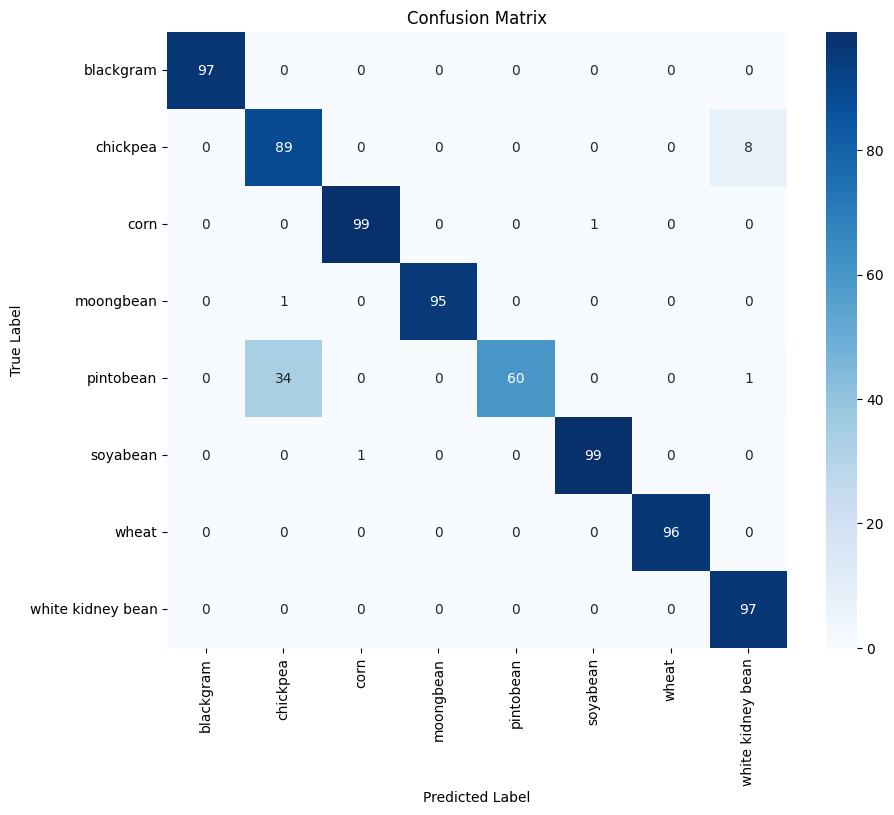

Classification Report:
                   precision    recall  f1-score   support

        blackgram       1.00      1.00      1.00        97
         chickpea       0.72      0.92      0.81        97
             corn       0.99      0.99      0.99       100
        moongbean       1.00      0.99      0.99        96
        pintobean       1.00      0.63      0.77        95
         soyabean       0.99      0.99      0.99       100
            wheat       1.00      1.00      1.00        96
white kidney bean       0.92      1.00      0.96        97

         accuracy                           0.94       778
        macro avg       0.95      0.94      0.94       778
     weighted avg       0.95      0.94      0.94       778



In [2]:
# **Confusion Matrix & Classification Report**
def evaluate_model(model, val_gen):
    y_true = []
    y_pred = []
    
    for i in range(len(val_gen)):
        img_batch, label_batch = val_gen[i]
        preds = model.predict(img_batch)
        y_true.extend(np.argmax(label_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=val_gen.class_indices.keys(), yticklabels=val_gen.class_indices.keys())
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()
    
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys()))

evaluate_model(alexnet_model, val_gen)

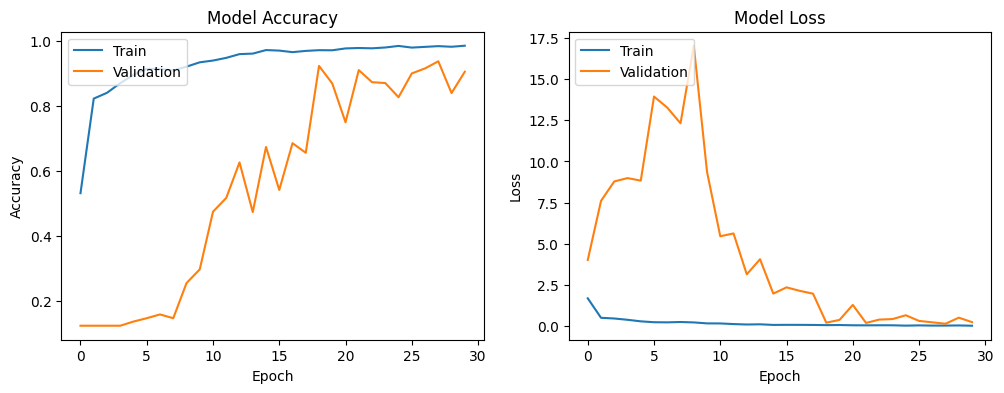

In [3]:
# **Plot Training and Validation Accuracy and Loss**
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step


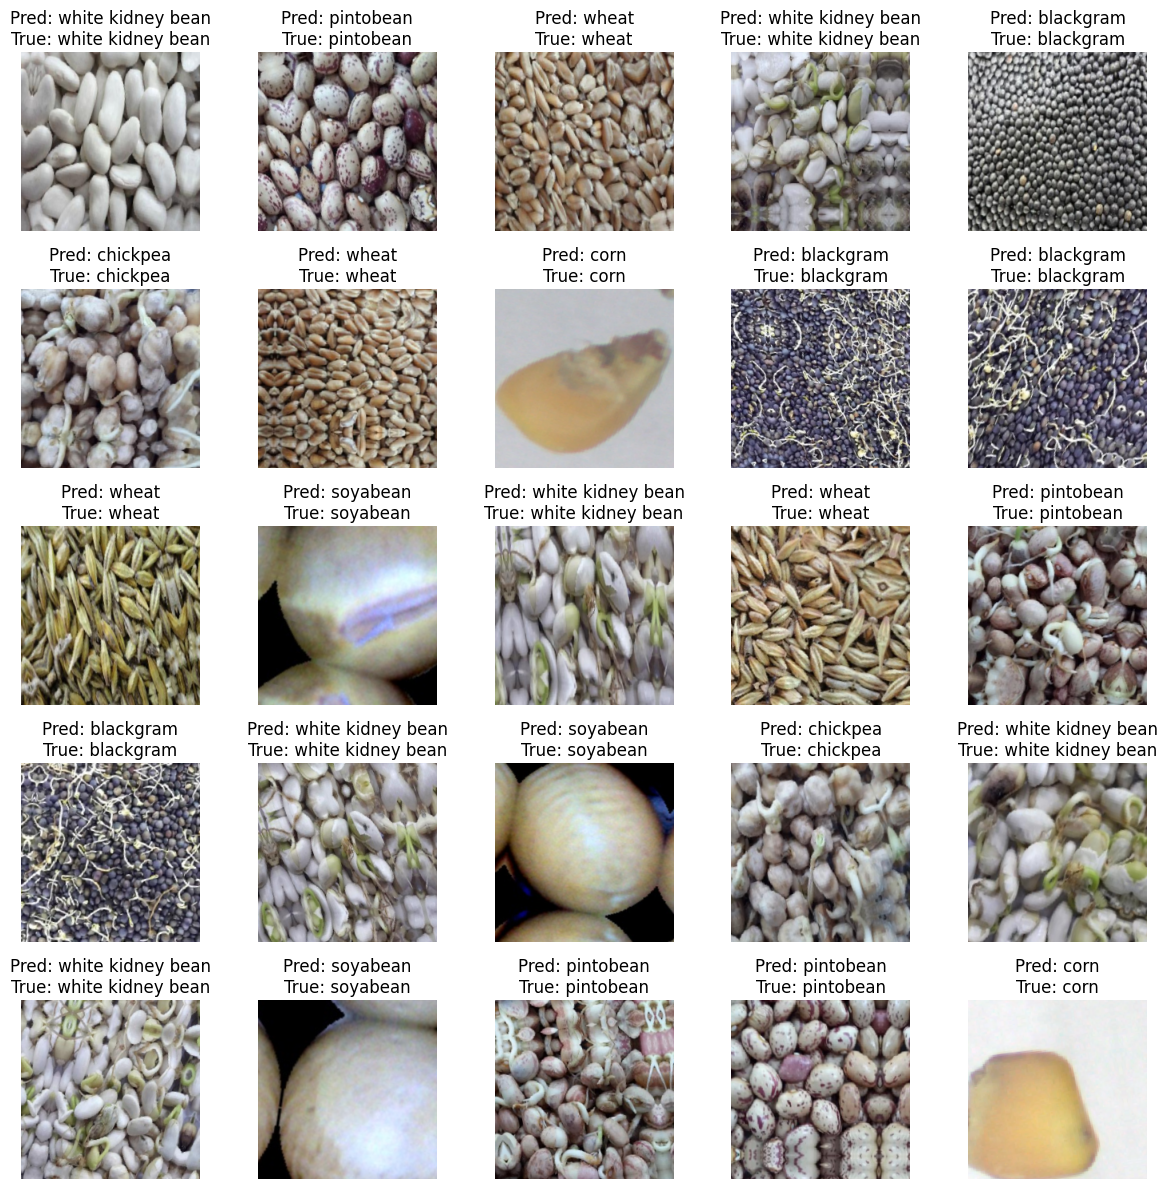

In [4]:
# **Visualizing Predictions on Validation Data**
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
axes = axes.flatten()

class_labels = list(val_gen.class_indices.keys())  # Get class labels

for i in range(25):
    img_batch, label_batch = next(val_gen)  # Corrected to use next()
    
    img = img_batch[0]  # Extract first image from batch
    label = label_batch[0]  # Extract first label from batch
    
    pred = alexnet_model.predict(np.expand_dims(img, axis=0))  # Predict
    pred_label = class_labels[np.argmax(pred[0])]  # Get predicted class
    true_label = class_labels[np.argmax(label)]  # Get true class
    
    axes[i].imshow(img)  # Display Image
    axes[i].set_title(f"Pred: {pred_label}\nTrue: {true_label}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()


In [5]:
test_loss, test_acc = alexnet_model.evaluate(val_gen)
print(f"Test Accuracy: {test_acc:.4f}")

13/13 ━━━━━━━━━━━━━━━━━━━━ 36s 3s/step - accuracy: 0.9380 - loss: 0.1594
Test Accuracy: 0.9370


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 655ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 664ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 714ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 658ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 657ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 686ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 661ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 651ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 646ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 627ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step


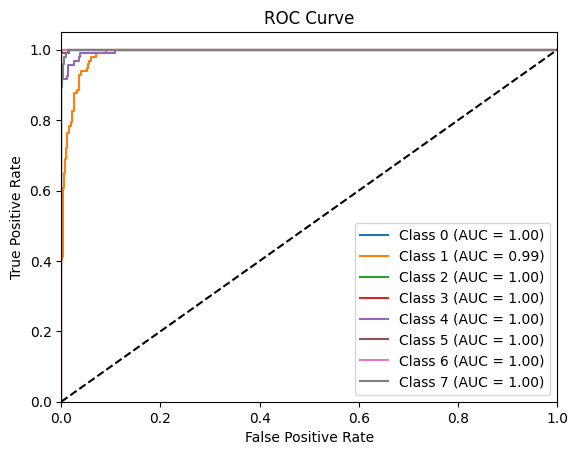

In [6]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get the true labels and predicted probabilities
y_true = []
y_probs = []

for i in range(len(val_gen)):
    img_batch, label_batch = val_gen[i]
    preds = alexnet_model.predict(img_batch)
    y_true.extend(label_batch)
    y_probs.extend(preds)

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# Compute ROC curve and AUC for each class
n_classes = y_true.shape[1]
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()


In [7]:
from sklearn.metrics import cohen_kappa_score

# Get predicted and true labels
y_pred_labels = np.argmax(y_probs, axis=1)
y_true_labels = np.argmax(y_true, axis=1)

# Compute Kappa Score
kappa = cohen_kappa_score(y_true_labels, y_pred_labels)
print(f"Cohen's Kappa Score: {kappa:.4f}")


Cohen's Kappa Score: 0.9354


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Predicted Class: wheat


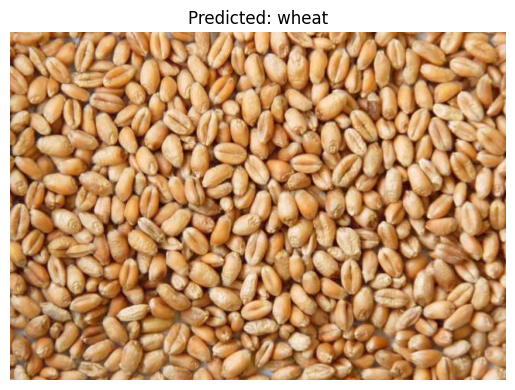

In [8]:
import cv2
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# Load and preprocess a sample image
image_path = "C:/Users/DELL/OneDrive/Documents/majorProject/wheat sample image.jpg"  # Replace with the actual image path
image = load_img(image_path, target_size=(224, 224))  # Resize to match model input size
image = img_to_array(image) / 255.0  # Normalize
image = np.expand_dims(image, axis=0)  # Add batch dimension

# Make prediction
pred = alexnet_model.predict(image)
predicted_class = np.argmax(pred[0])  # Get class index
class_labels = list(val_gen.class_indices.keys())  # Retrieve class labels
predicted_label = class_labels[predicted_class]

# Display result
print(f"Predicted Class: {predicted_label}")

# Show image with prediction
import matplotlib.pyplot as plt
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB
plt.imshow(img)
plt.title(f"Predicted: {predicted_label}")
plt.axis("off")
plt.show()


In [10]:
# **Compute Accuracy for Each Seed Type**
def compute_classwise_accuracy(model, val_gen):
    y_true = []
    y_pred = []
    
    for i in range(len(val_gen)):
        img_batch, label_batch = val_gen[i]
        preds = model.predict(img_batch)
        y_true.extend(np.argmax(label_batch, axis=1))
        y_pred.extend(np.argmax(preds, axis=1))
    
    report = classification_report(y_true, y_pred, target_names=val_gen.class_indices.keys(), output_dict=True)
    
    print("Class-wise Accuracy:")
    for class_name, metrics in report.items():
        if isinstance(metrics, dict):
            print(f"{class_name}: {metrics['precision'] * 100:.2f}%")

compute_classwise_accuracy(alexnet_model, val_gen)


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 257ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 249ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
Class-wise Accuracy:
blackgram: 100.00%
chickpea: 69.70%
corn: 100.00%
moongbean: 100.00%
pintobean: 100.00%
soyabean: 100.00%
wheat: 100.00%
white kidney bean: 89.62%
macro avg: 94.91%
weighted avg: 94.93%
